<a href="https://colab.research.google.com/github/lariscardoz4/project/blob/main/Linear_Regression_Boston_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load the boston housing data set
boston = fetch_openml(name='boston', version=1, as_frame=True)
X = boston.data
print(X)
y = boston.target

        CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  \
0    0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0   
1    0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0   
2    0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0   
3    0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0   
4    0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0   
..       ...   ...    ...  ...    ...    ...   ...     ...  ..    ...   
501  0.06263   0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0   
502  0.04527   0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0   
503  0.06076   0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0   
504  0.10959   0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0   
505  0.04741   0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4.03  
3  

In [ ]:
# View the first 5 rows of the features (X)
display(X.head())

# View the first 10 rows of the target (y)
display(y.head(10))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
5,28.7
6,22.9
7,27.1
8,16.5
9,18.9


### Viewing the last few rows

In [ ]:
# View the last 5 rows of the features (X)
display(X.tail())

# View the last 3 rows of the target (y)
display(y.tail(3))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88


,MEDV
503,23.9
504,22.0
505,11.9


### Viewing specific rows by index

In [ ]:
# View rows from index 10 to 14 of the features (X)
display(X.iloc[10:15])

# View rows from index 20 to 22 of the target (y)
display(y.iloc[20:23])

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
10,0.22489,12.5,7.87,0,0.524,6.377,94.3,6.3467,5,311.0,15.2,392.52,20.45
11,0.11747,12.5,7.87,0,0.524,6.009,82.9,6.2267,5,311.0,15.2,396.90,13.27
12,0.09378,12.5,7.87,0,0.524,5.889,39.0,5.4509,5,311.0,15.2,390.50,15.71
13,0.62976,0.0,8.14,0,0.538,5.949,61.8,4.7075,4,307.0,21.0,396.90,8.26
14,0.63796,0.0,8.14,0,0.538,6.096,84.5,4.4619,4,307.0,21.0,380.02,10.26


,MEDV
20,13.6
21,19.6
22,15.2


In [ ]:
#iloc means integer location based indexing
# Example of .iloc
print('Using .iloc:')

# Get the row at integer position 2 (3rd row)
display(X.iloc[2])

# Get rows from integer position 0 up to (but not including) 3
display(X.iloc[0:3])

# Get a specific cell: row at integer position 1, column at integer position 4
display(X.iloc[1, 4])

# Get all rows, but only columns at integer positions 0, 1, and 2
display(X.iloc[:, 0:3].head())



Using .iloc:


,2
CRIM,0.02729
ZN,0.0
INDUS,7.07
CHAS,0
NOX,0.469
RM,7.185
AGE,61.1
DIS,4.9671
RAD,2
TAX,242.0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03


np.float64(0.469)

,CRIM,ZN,INDUS
0,0.00632,18.0,2.31
1,0.02731,0.0,7.07
2,0.02729,0.0,7.07
3,0.03237,0.0,2.18
4,0.06905,0.0,2.18


In [ ]:
# loc means label location based indexing
# Example of .loc
print('\nUsing .loc:')

# Get the row with label index 2
display(X.loc[2])

# Get rows with label indices 0, 1, and 2 (inclusive)
display(X.loc[0:2])

# Get all rows, but only columns 'CRIM', 'ZN', and 'INDUS'
display(X.loc[:, ['CRIM', 'ZN', 'INDUS']].head())


Using .loc:


,2
CRIM,0.02729
ZN,0.0
INDUS,7.07
CHAS,0
NOX,0.469
RM,7.185
AGE,61.1
DIS,4.9671
RAD,2
TAX,242.0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03


,CRIM,ZN,INDUS
0,0.00632,18.0,2.31
1,0.02731,0.0,7.07
2,0.02729,0.0,7.07
3,0.03237,0.0,2.18
4,0.06905,0.0,2.18


### Viewing specific columns (for X only)

In [ ]:
# View a specific column from X, e.g., 'CRIM' (Crime Rate)
display(X['CRIM'].head())

# View multiple columns from X
display(X[['CRIM', 'LSTAT', 'RM']].head())

,CRIM
0,0.00632
1,0.02731
2,0.02729
3,0.03237
4,0.06905


,CRIM,LSTAT,RM
0,0.00632,4.98,6.575
1,0.02731,9.14,6.421
2,0.02729,4.03,7.185
3,0.03237,2.94,6.998
4,0.06905,5.33,7.147


In [ ]:
#Selecting a single feature for simplicity: 'RM'(Average no. of rooms)
X_rm = X['RM'].values.reshape(-1,1) #reshaping the array from 1D array to 2D array with one row and (as many columns in the data) columns.

In [ ]:
#Splitting the data in training and testing models.
X_train, X_test, y_train, y_test = train_test_split(X_rm, y, test_size=0.3, random_state=42)

In [ ]:
#Transform the feature to include polynomial terms.
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_poly)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared error: 32.15
R-squared: 0.57


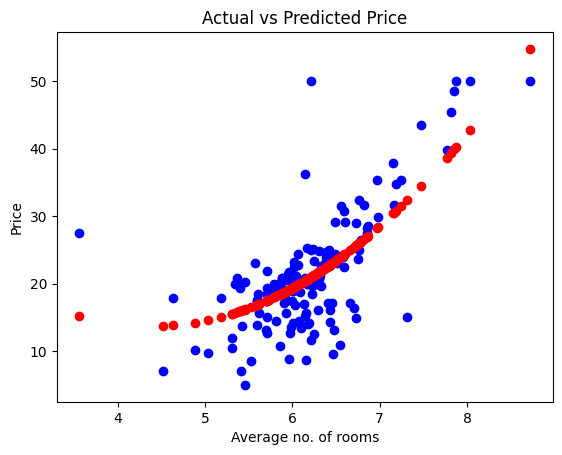

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual Price')
plt.scatter(X_test, y_pred, color='red', label='Predicted Price')
plt.xlabel('Average no. of rooms')
plt.ylabel('Price')
plt.title('Actual vs Predicted Price')
plt.show()